Importing plotly failed. Interactive plots will not work.
15:28:33 - cmdstanpy - INFO - Chain [1] start processing
15:28:33 - cmdstanpy - INFO - Chain [1] done processing


Best XGB-direct params: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_lambda': 1.0} MAE: 36.49
Best Hybrid residual XGB params: {'n_estimators': 500, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_lambda': 1.0} MAE: 47.85

=== Test (2025-01..07) Sonuçları ===
Prophet                      -> MAE:  72.17 | RMSE:  84.65 | MAPE:  58.29%
XGB-direct (orders+stock)    -> MAE:  36.49 | RMSE:  57.34 | MAPE:  32.60%
Hybrid (Prophet+resid)       -> MAE:  47.85 | RMSE:  58.43 | MAPE:  31.87%


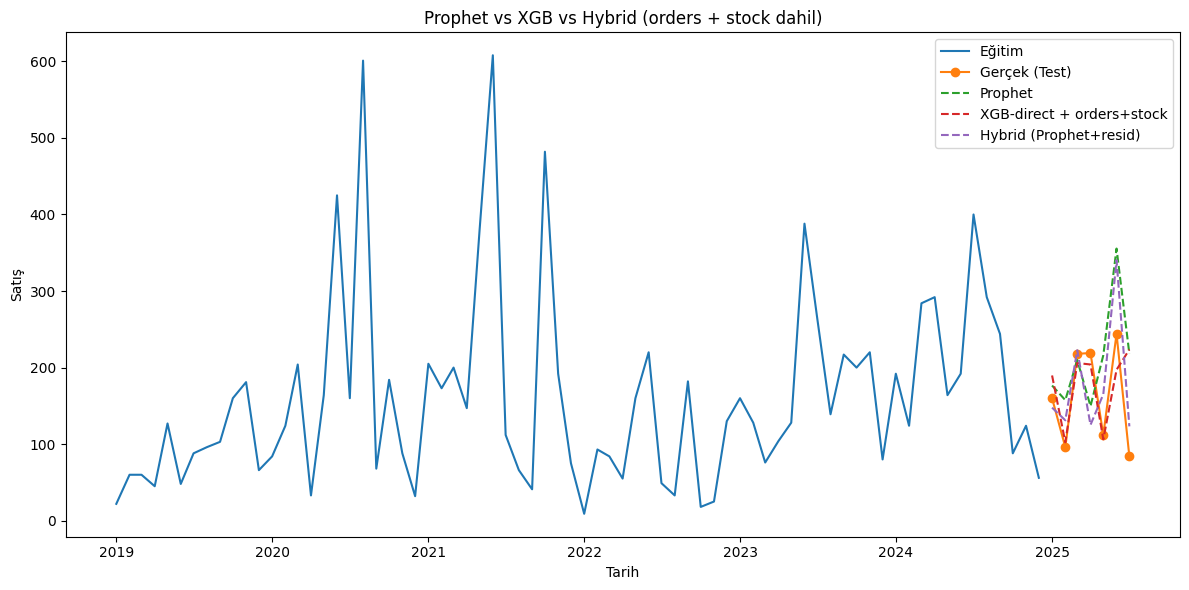

In [1]:
# =========================================================
#  Sales + Orders + Stocks  → Prophet / XGB / Hybrid
#  Train: 2019-01 .. 2024-12 (MS)
#  Test : 2025-01 .. 2025-07  (MS)
#  Features: month, year, is_summer, is_winter, lag1, lag12, orders, stock
#  (İsteğe bağlı) küçük XGBoost parametre araması
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from io import StringIO
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------- 0) AYARLAR --------------------
TRAIN_END  = pd.Timestamp("2024-12-01")
TEST_START = pd.Timestamp("2025-01-01")
TEST_END   = pd.Timestamp("2025-07-01")
OPTIMIZE_XGB = True  # küçük bir grid araması için True/False

# -------------------- 1) SATIŞ VERİSİ --------------------
sales_data = {
"2019-01":22,"2019-02":60,"2019-03":60,"2019-04":45,"2019-05":127,
"2019-06":48,"2019-07":88,"2019-08":96,"2019-09":103,"2019-10":160,
"2019-11":181,"2019-12":66,"2020-01":84,"2020-02":124,"2020-03":204,
"2020-04":33,"2020-05":164,"2020-06":425,"2020-07":160,"2020-08":601,
"2020-09":68,"2020-10":184,"2020-11":88,"2020-12":32,"2021-01":205,
"2021-02":173,"2021-03":200,"2021-04":147,"2021-05":380,"2021-06":608,
"2021-07":112,"2021-08":66,"2021-09":41,"2021-10":482,"2021-11":192,
"2021-12":75,"2022-01":9,"2022-02":93,"2022-03":84,"2022-04":55,
"2022-05":160,"2022-06":220,"2022-07":49,"2022-08":33,"2022-09":182,
"2022-10":18,"2022-11":25,"2022-12":130,"2023-01":160,"2023-02":128,
"2023-03":76,"2023-04":104,"2023-05":128,"2023-06":388,"2023-07":264,
"2023-08":139,"2023-09":217,"2023-10":200,"2023-11":220,"2023-12":80,
"2024-01":192,"2024-02":124,"2024-03":284,"2024-04":292,"2024-05":164,
"2024-06":192,"2024-07":400,"2024-08":292,"2024-09":244,"2024-10":88,
"2024-11":124,"2024-12":56,"2025-01":160,"2025-02":96,"2025-03":218,
"2025-04":219,"2025-05":112,"2025-06":244,"2025-07":84
}
sales = pd.Series(sales_data)
sales.index = pd.to_datetime(sales.index)   # bunlar ay başı (MS)

# -------------------- 2) SİPARİŞ VERİSİ --------------------
orders_raw = """SalesYear SalesMonth TotalQty
2019 1 16
2019 2 64
2019 3 72
2019 4 37
2019 5 135
2019 6 48
2019 7 96
2019 8 132
2019 9 137
2019 10 136
2019 11 173
2019 12 67
2020 1 64
2020 2 624
2020 3 197
2020 4 33
2020 5 164
2020 6 617
2020 7 132
2020 8 636
2020 9 56
2020 10 224
2020 11 48
2020 12 32
2021 1 249
2021 2 233
2021 3 368
2021 4 447
2021 5 596
2021 6 360
2021 7 144
2021 8 61
2021 9 378
2021 10 454
2021 11 228
2021 12 79
2022 1 6
2022 2 117
2022 3 92
2022 4 70
2022 5 240
2022 6 292
2022 7 57
2022 8 36
2022 9 222
2022 10 20
2022 11 40
2022 12 134
2023 1 229
2023 2 112
2023 3 80
2023 4 113
2023 5 160
2023 6 480
2023 7 252
2023 8 219
2023 9 173
2023 10 408
2023 11 196
2023 12 136
2024 1 284
2024 2 404
2024 3 324
2024 4 288
2024 5 158
2024 6 216
2024 7 760
2024 8 396
2024 9 249
2024 10 84
2024 11 128
2024 12 56
2025 1 176
2025 2 96
2025 3 256
2025 4 216
2025 5 136
2025 6 244
2025 7 192
2025 8 197
"""
orders = pd.read_csv(StringIO(orders_raw), sep=r"\s+")
orders["ds"] = pd.to_datetime(orders["SalesYear"].astype(str) + "-" +
                              orders["SalesMonth"].astype(str) + "-01")
orders = orders[["ds","TotalQty"]].rename(columns={"TotalQty":"orders"})

# -------------------- 3) STOK VERİSİ (CSV FORMATI) --------------------
stocks_csv = """ItemCode,MonthStart,AyBasi_Stok
303-104092,2019-01-01,0
303-104092,2019-02-01,-22
303-104092,2019-03-01,-2
303-104092,2019-04-01,38
303-104092,2019-05-01,-7
303-104092,2019-06-01,-14
303-104092,2019-07-01,-28
303-104092,2019-08-01,4
303-104092,2019-09-01,68
303-104092,2019-10-01,1
303-104092,2019-11-01,105
303-104092,2019-12-01,84
303-104092,2020-01-01,18
303-104092,2020-02-01,54
303-104092,2020-03-01,70
303-104092,2020-04-01,349
303-104092,2020-05-01,356
303-104092,2020-06-01,192
303-104092,2020-07-01,166
303-104092,2020-08-01,262
303-104092,2020-09-01,181
303-104092,2020-10-01,165
303-104092,2020-11-01,1
303-104092,2020-12-01,133
303-104092,2021-01-01,117
303-104092,2021-02-01,32
303-104092,2021-03-01,31
303-104092,2021-04-01,111
303-104092,2021-05-01,128
303-104092,2021-06-01,-12
303-104092,2021-07-01,244
303-104092,2021-08-01,172
303-104092,2021-09-01,138
303-104092,2021-10-01,577
303-104092,2021-11-01,95
303-104092,2021-12-01,23
303-104092,2022-01-01,104
303-104092,2022-02-01,94
303-104092,2022-03-01,149
303-104092,2022-04-01,157
303-104092,2022-05-01,102
303-104092,2022-06-01,262
303-104092,2022-07-01,281
303-104092,2022-08-01,232
303-104092,2022-09-01,199
303-104092,2022-10-01,181
303-104092,2022-11-01,223
303-104092,2022-12-01,198
303-104092,2023-01-01,68
303-104092,2023-02-01,76
303-104092,2023-03-01,48
303-104092,2023-04-01,92
303-104092,2023-05-01,28
303-104092,2023-06-01,100
303-104092,2023-07-01,212
303-104092,2023-08-01,188
303-104092,2023-09-01,49
303-104092,2023-10-01,132
303-104092,2023-11-01,92
303-104092,2023-12-01,32
303-104092,2024-01-01,-8
303-104092,2024-02-01,104
303-104092,2024-03-01,-12
303-104092,2024-04-01,144
303-104092,2024-05-01,72
303-104092,2024-06-01,216
303-104092,2024-07-01,24
303-104092,2024-08-01,4
303-104092,2024-09-01,248
303-104092,2024-10-01,216
303-104092,2024-11-01,127
303-104092,2024-12-01,167
303-104092,2025-01-01,153
303-104092,2025-02-01,145
303-104092,2025-03-01,97
303-104092,2025-04-01,78
303-104092,2025-05-01,139
303-104092,2025-06-01,187
303-104092,2025-07-01,35
303-104092,2025-08-01,-29
303-104092,2025-09-01,130
"""
stocks = pd.read_csv(StringIO(stocks_csv))
stocks["ds"] = pd.to_datetime(stocks["MonthStart"])
stocks = stocks[["ds","AyBasi_Stok"]].rename(columns={"AyBasi_Stok":"stock"})

# -------------------- 4) BİRLEŞTİR --------------------
df = pd.DataFrame({"ds": sales.index, "y": sales.values})\
       .merge(orders, on="ds", how="left")\
       .merge(stocks, on="ds", how="left")

# -------------------- 5) TRAIN / TEST --------------------
train_df = df[df["ds"] <= TRAIN_END].copy()
test_df  = df[(df["ds"] >= TEST_START) & (df["ds"] <= TEST_END)].copy()
y_true   = test_df["y"].to_numpy()

# -------------------- 6) PROPHET --------------------
m = Prophet(yearly_seasonality=True, weekly_seasonality=False)
m.fit(train_df[["ds","y"]])
future = m.make_future_dataframe(periods=len(test_df), freq="MS")
fcst   = m.predict(future)[["ds","yhat"]]
df     = df.merge(fcst, on="ds", how="left")
prophet_test_pred = df.loc[(df["ds"]>=TEST_START) & (df["ds"]<=TEST_END), "yhat"].to_numpy()

# -------------------- 7) FEATURE ENGINEERING --------------------
def add_features(z):
    z = z.copy()
    z["month"] = z["ds"].dt.month
    z["year"] = z["ds"].dt.year
    z["is_summer"] = z["ds"].dt.month.isin([6,7,8]).astype(int)
    z["is_winter"] = z["ds"].dt.month.isin([12,1,2]).astype(int)
    z["lag1"]  = z["y"].shift(1)
    z["lag12"] = z["y"].shift(12)
    return z

feat = add_features(df)

# -------------------- 8) XGB (DIRECT)  orders + stock --------------------
mask_train_direct = feat["ds"] <= TRAIN_END
mask_test_direct  = (feat["ds"]>=TEST_START) & (feat["ds"]<=TEST_END)

X_cols_direct = ["month","year","is_summer","is_winter","orders","stock"]
X_train_direct = feat.loc[mask_train_direct, X_cols_direct]
y_train_direct = feat.loc[mask_train_direct, "y"]
X_test_direct  = feat.loc[mask_test_direct,  X_cols_direct]

if OPTIMIZE_XGB:
    # küçük grid
    grid = [
        {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 3, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 1.0},
        {"n_estimators": 500, "learning_rate": 0.05, "max_depth": 3, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 1.0},
        {"n_estimators": 500, "learning_rate": 0.10, "max_depth": 3, "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 1.0},
    ]
    best_mae, best_params, best_model = np.inf, None, None
    for g in grid:
        mdl = XGBRegressor(random_state=42, **g)
        mdl.fit(X_train_direct, y_train_direct)
        pred = mdl.predict(X_test_direct)
        mae  = mean_absolute_error(y_true, pred)
        if mae < best_mae:
            best_mae, best_params, best_model = mae, g, mdl
    xgb_direct = best_model
    print("Best XGB-direct params:", best_params, "MAE:", round(best_mae,2))
else:
    xgb_direct = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=3,
                              subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0, random_state=42)
    xgb_direct.fit(X_train_direct, y_train_direct)

xgb_direct_pred = xgb_direct.predict(X_test_direct)

# -------------------- 9) HYBRID (Prophet + XGB-RESIDUAL) --------------------
feat["residual"] = feat["y"] - feat["yhat"]

mask_train_res = (feat["ds"] <= TRAIN_END) & feat[["lag1","lag12"]].notna().all(axis=1)
train_res = feat.loc[mask_train_res].copy()

X_cols_res = ["month","year","is_summer","is_winter","lag1","lag12","orders","stock"]
X_res_train = train_res[X_cols_res]
y_res_train = train_res["residual"]

if OPTIMIZE_XGB:
    grid_res = [
        {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 3, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 1.0},
        {"n_estimators": 500, "learning_rate": 0.05, "max_depth": 3, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 1.0},
        {"n_estimators": 500, "learning_rate": 0.10, "max_depth": 3, "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 1.0},
    ]
    best_mae, best_params, best_model = np.inf, None, None
    for g in grid_res:
        mdl = XGBRegressor(random_state=42, **g)
        mdl.fit(X_res_train, y_res_train)
        resid_pred = mdl.predict(feat.loc[mask_test_direct, X_cols_res])
        prophet_part = prophet_test_pred
        y_pred = prophet_part + resid_pred
        mae = mean_absolute_error(y_true, y_pred)
        if mae < best_mae:
            best_mae, best_params, best_model = mae, g, mdl
    xgb_res = best_model
    print("Best Hybrid residual XGB params:", best_params, "MAE:", round(best_mae,2))
else:
    xgb_res = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=3,
                           subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0, random_state=42)
    xgb_res.fit(X_res_train, y_res_train)

resid_pred_test = xgb_res.predict(feat.loc[mask_test_direct, X_cols_res])
hybrid_pred = prophet_test_pred + resid_pred_test

# -------------------- 10) METRİKLER --------------------
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1, y_true))) * 100

def report(name, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mp   = mape(y_true, y_pred)
    print(f"{name:28s} -> MAE: {mae:6.2f} | RMSE: {rmse:6.2f} | MAPE: {mp:6.2f}%")
    return mae, rmse, mp

print("\n=== Test (2025-01..07) Sonuçları ===")
_ = report("Prophet", prophet_test_pred)
_ = report("XGB-direct (orders+stock)", xgb_direct_pred)
_ = report("Hybrid (Prophet+resid)", hybrid_pred)

# -------------------- 11) GRAFİK --------------------
plt.figure(figsize=(12,6))
plt.plot(train_df["ds"], train_df["y"], label="Eğitim")
plt.plot(test_df["ds"],  test_df["y"],  "o-", label="Gerçek (Test)")
plt.plot(test_df["ds"],  prophet_test_pred, "--", label="Prophet")
plt.plot(test_df["ds"],  xgb_direct_pred,  "--", label="XGB-direct + orders+stock")
plt.plot(test_df["ds"],  hybrid_pred,      "--", label="Hybrid (Prophet+resid)")
plt.title("Prophet vs XGB vs Hybrid (orders + stock dahil)")
plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
plt.show()
